# 01. Preprocesamiento de Bank Marketing

Este cuaderno descarga el conjunto Bank Marketing desde la fuente oficial de UCI, carga la versión `bank-full.csv` y prepara los dos escenarios de clasificación usados en el TFG: con `duration` y sin `duration`.


In [1]:
import io
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import requests

from pathlib import Path
from sklearn.model_selection import train_test_split


## 1. Descarga y carga del dataset


In [2]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank%2Bmarketing.zip"

respuesta = requests.get(BANK_URL, timeout=120)
respuesta.raise_for_status()

with zipfile.ZipFile(io.BytesIO(respuesta.content)) as zip_principal:
    archivos_zip_principal = zip_principal.namelist()
    with zip_principal.open("bank.zip") as zip_interno:
        with zipfile.ZipFile(io.BytesIO(zip_interno.read())) as zip_bank:
            archivos_zip_bank = zip_bank.namelist()
            with zip_bank.open("bank-full.csv") as archivo:
                bank = pd.read_csv(archivo, sep=";")

resumen_carga = pd.DataFrame([{
    "dataset": "Bank Marketing",
    "filas": bank.shape[0],
    "columnas": bank.shape[1],
    "archivo_utilizado": "bank-full.csv",
}])

display(resumen_carga)
bank.head()


,dataset,filas,columnas,archivo_utilizado
0,Bank Marketing,45211,17,bank-full.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Revisión inicial


In [3]:
tabla_tipos = pd.DataFrame({
    "variable": bank.columns,
    "tipo": [str(bank[col].dtype) for col in bank.columns],
    "valores_unicos": [bank[col].nunique(dropna=False) for col in bank.columns],
    "nulos": [bank[col].isna().sum() for col in bank.columns],
})

display(tabla_tipos)

tabla_unknown = pd.DataFrame([
    {"variable": col, "n_unknown": int((bank[col] == "unknown").sum())}
    for col in [col for col in bank.columns if not pd.api.types.is_numeric_dtype(bank[col])]
])

display(tabla_unknown)


,variable,tipo,valores_unicos,nulos
0,age,int64,77,0
1,job,str,12,0
2,marital,str,3,0
3,education,str,4,0
4,default,str,2,0
5,balance,int64,7168,0
6,housing,str,2,0
7,loan,str,2,0
8,contact,str,3,0
9,day,int64,31,0


,variable,n_unknown
0,job,288
1,marital,0
2,education,1857
3,default,0
4,housing,0
5,loan,0
6,contact,13020
7,month,0
8,poutcome,36959
9,y,0


## 3. Variable objetivo y `duration`


,clase,frecuencia,porcentaje
0,no,39922,0.883015
1,yes,5289,0.116985


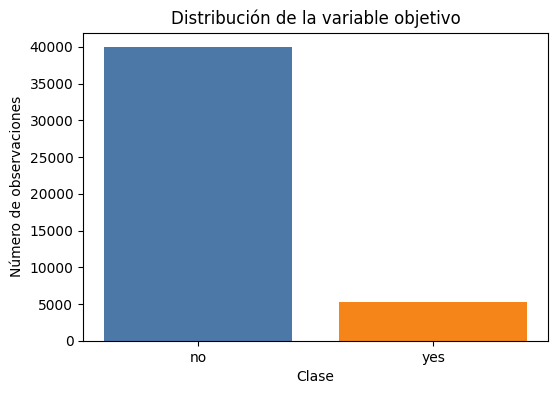

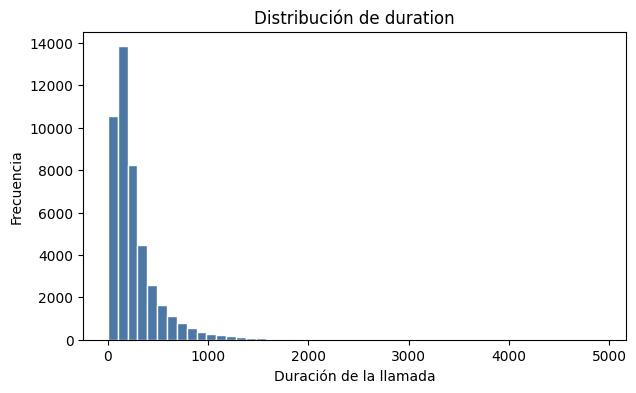

In [4]:
distribucion_objetivo = (
    bank["y"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="frecuencia")
)
distribucion_objetivo["porcentaje"] = distribucion_objetivo["frecuencia"] / len(bank)

display(distribucion_objetivo)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(distribucion_objetivo["clase"], distribucion_objetivo["frecuencia"], color=["#4c78a8", "#f58518"])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de observaciones")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bank["duration"], bins=50, color="#4c78a8", edgecolor="white")
ax.set_title("Distribución de duration")
ax.set_xlabel("Duración de la llamada")
ax.set_ylabel("Frecuencia")
plt.show()


## 4. Preparación de escenarios


In [5]:
bank_modelo = bank.copy()
bank_modelo["y"] = bank_modelo["y"].map({"no": 0, "yes": 1})

variables_con_duration = [col for col in bank_modelo.columns if col != "y"]
variables_sin_duration = [col for col in variables_con_duration if col != "duration"]

bank_train, bank_test = train_test_split(
    bank_modelo,
    test_size=0.20,
    random_state=42,
    stratify=bank_modelo["y"],
)

Path("data/processed/serie_computacional").mkdir(parents=True, exist_ok=True)
Path("reports/tables/serie_computacional").mkdir(parents=True, exist_ok=True)
Path("reports/figures/serie_computacional").mkdir(parents=True, exist_ok=True)

bank_train[variables_con_duration + ["y"]].to_csv(
    "data/processed/serie_computacional/bank_train_con_duration.csv",
    index=False,
)
bank_test[variables_con_duration + ["y"]].to_csv(
    "data/processed/serie_computacional/bank_test_con_duration.csv",
    index=False,
)
bank_train[variables_sin_duration + ["y"]].to_csv(
    "data/processed/serie_computacional/bank_train_sin_duration.csv",
    index=False,
)
bank_test[variables_sin_duration + ["y"]].to_csv(
    "data/processed/serie_computacional/bank_test_sin_duration.csv",
    index=False,
)

tabla_tipos.to_csv("reports/tables/serie_computacional/bank_tipos_variables.csv", index=False)
tabla_unknown.to_csv("reports/tables/serie_computacional/bank_unknown_por_variable.csv", index=False)
distribucion_objetivo.to_csv("reports/tables/serie_computacional/bank_distribucion_objetivo.csv", index=False)

resumen_splits = pd.DataFrame([
    {"escenario": "con_duration", "split": "train", "filas": len(bank_train), "variables": len(variables_con_duration), "tasa_yes": bank_train["y"].mean()},
    {"escenario": "con_duration", "split": "test", "filas": len(bank_test), "variables": len(variables_con_duration), "tasa_yes": bank_test["y"].mean()},
    {"escenario": "sin_duration", "split": "train", "filas": len(bank_train), "variables": len(variables_sin_duration), "tasa_yes": bank_train["y"].mean()},
    {"escenario": "sin_duration", "split": "test", "filas": len(bank_test), "variables": len(variables_sin_duration), "tasa_yes": bank_test["y"].mean()},
])

resumen_splits.to_csv("reports/tables/serie_computacional/bank_resumen_splits.csv", index=False)

resumen_splits


,escenario,split,filas,variables,tasa_yes
0,con_duration,train,36168,16,0.116982
1,con_duration,test,9043,16,0.116997
2,sin_duration,train,36168,15,0.116982
3,sin_duration,test,9043,15,0.116997
